# 🔮 Notebook 4: Facebook Prophet Forecast
### StockSense AI — Seasonal Decomposition Model

In [3]:
import sys
!{sys.executable} -m pip install prophet

In [4]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, warnings
warnings.filterwarnings('ignore')
print('✅ Prophet ready')

/opt/anaconda3/envs/ai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Prophet ready


## 1. Load & Format Data

In [6]:
TICKER = 'AAPL'
df = pd.read_csv(f'../data/{TICKER}_processed.csv', index_col=0, parse_dates=True)

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Force numeric, drop bad rows
df = df.apply(pd.to_numeric, errors='coerce')

# Reset index and filter only valid dates
prophet_df = df[['Close']].reset_index()
prophet_df.columns = ['ds', 'y']

# Drop rows where ds cannot be parsed as a date (e.g. 'AAPL' ticker rows)
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], errors='coerce')
prophet_df = prophet_df.dropna(subset=['ds', 'y']).reset_index(drop=True)

print(f'Data shape: {prophet_df.shape}')
prophet_df.head()

Data shape: (1561, 2)


,ds,y
0,2018-10-16,52.573982
1,2018-10-17,52.346786
2,2018-10-18,51.123260
3,2018-10-19,51.901859
4,2018-10-22,52.218990


## 2. Train / Test Split

In [7]:
SPLIT = int(len(prophet_df) * 0.85)
train_df = prophet_df[:SPLIT]
test_df  = prophet_df[SPLIT:]
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')

Train: 1326  |  Test: 235


## 3. Fit Prophet Model

In [8]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.1,      # flexibility of trend
    seasonality_prior_scale=10,
    interval_width=0.95
)

# Add US stock market holidays
model.add_country_holidays(country_name='US')

model.fit(train_df)
print('✅ Prophet model fitted')

22:57:24 - cmdstanpy - INFO - Chain [1] start processing
22:57:26 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted


## 4. Evaluate on Test Set

In [9]:
test_forecast = model.predict(test_df[['ds']])
y_pred = test_forecast['yhat'].values
y_true = test_df['y'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'Prophet Results')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')

Prophet Results
  RMSE : 22.8643
  MAE  : 18.1226
  MAPE : 9.66%


## 5. Forecast Plot

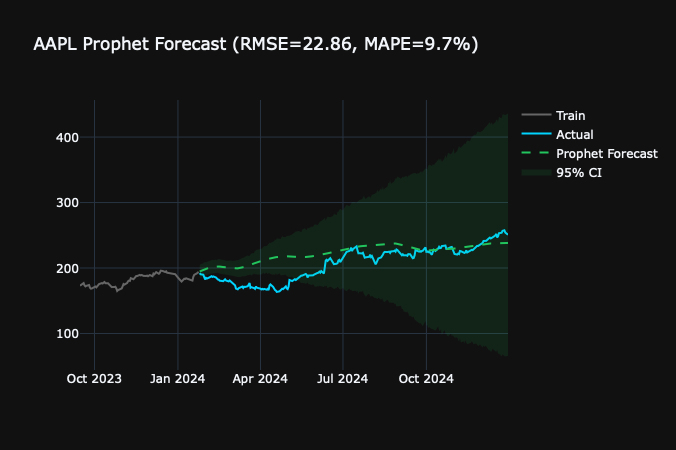

In [10]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df['ds'][-90:], y=train_df['y'][-90:],
    name='Train', line=dict(color='#666')))
fig.add_trace(go.Scatter(x=test_df['ds'], y=y_true,
    name='Actual', line=dict(color='#00d4ff')))
fig.add_trace(go.Scatter(x=test_forecast['ds'], y=y_pred,
    name='Prophet Forecast', line=dict(color='#22c55e', dash='dash')))
fig.add_trace(go.Scatter(
    x=list(test_forecast['ds']) + list(reversed(test_forecast['ds'])),
    y=list(test_forecast['yhat_upper']) + list(reversed(test_forecast['yhat_lower'])),
    fill='toself', fillcolor='rgba(34,197,94,0.1)',
    line=dict(color='rgba(0,0,0,0)'), name='95% CI'))
fig.update_layout(title=f'{TICKER} Prophet Forecast (RMSE={rmse:.2f}, MAPE={mape:.1f}%)',
    template='plotly_dark', height=450)
fig.show()

## 6. Components Plot (Trend + Seasonality)

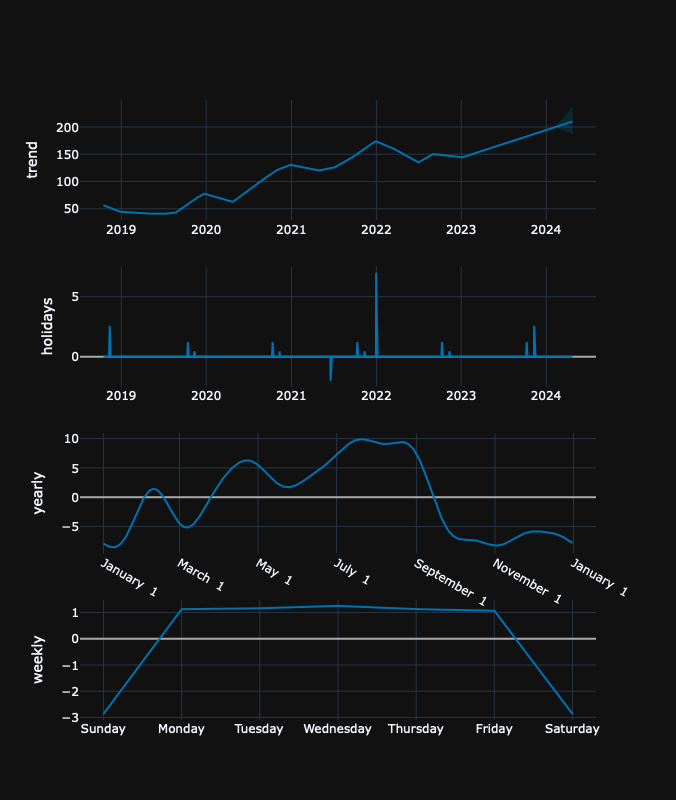

In [11]:
future = model.make_future_dataframe(periods=90)
full_forecast = model.predict(future)
fig_comp = plot_components_plotly(model, full_forecast)
fig_comp.update_layout(template='plotly_dark')
fig_comp.show()

## 7. 90-Day Future Forecast

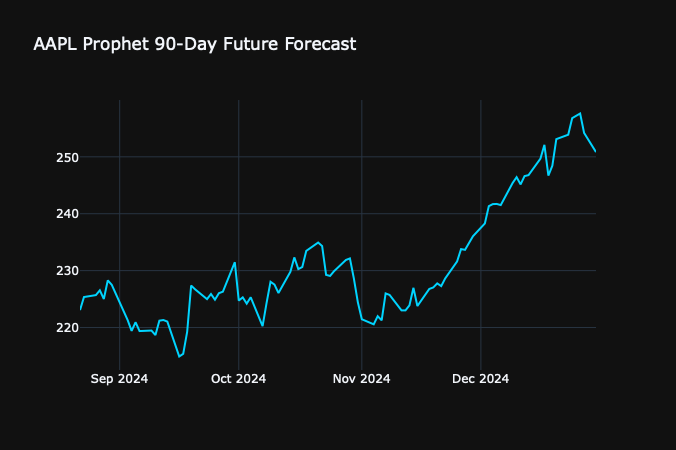

In [12]:
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=prophet_df['ds'][-90:], y=prophet_df['y'][-90:],
    name='Historical', line=dict(color='#00d4ff')))
future_only = full_forecast[full_forecast['ds'] > prophet_df['ds'].max()]
fig2.add_trace(go.Scatter(x=future_only['ds'], y=future_only['yhat'],
    name='Forecast', line=dict(color='#22c55e', dash='dash')))
fig2.add_trace(go.Scatter(
    x=list(future_only['ds']) + list(reversed(future_only['ds'])),
    y=list(future_only['yhat_upper']) + list(reversed(future_only['yhat_lower'])),
    fill='toself', fillcolor='rgba(34,197,94,0.1)',
    line=dict(color='rgba(0,0,0,0)'), name='Confidence Band'))
fig2.update_layout(title=f'{TICKER} Prophet 90-Day Future Forecast',
    template='plotly_dark', height=450)
fig2.show()

## 8. Save Model

In [13]:
joblib.dump(model, f'../models/saved_models/{TICKER}_prophet.pkl')
print('✅ Prophet model saved')

✅ Prophet model saved
